# Incremental Capstone: Regression, Classification, Clustering, and Recommendation

**UTD AI/ML Bootcamp**

This notebook applies four core machine learning workflows to four real-world business problems, end to end from data preparation through modeling, evaluation, and business interpretation.

| Task | Problem | Technique | Dataset |
|---|---|---|---|
| 1 | Predicting Bike Rental Demand | Regression (Linear, Lasso, Ridge) | `FloridaBikeRentals.csv` |
| 2 | Income Classification | Classification (six models, SMOTE) | `adultcensusincome.csv` |
| 3 | Credit Card User Segmentation | PCA + K-Means | `CC_GENERAL.csv` |
| 4 | Movie Recommendations | User-, item-, and model-based CF | `movies.csv`, `ratings.csv` |

**Requirements:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `imbalanced-learn`, `scikit-surprise`

All dataset files are expected in a `data/` folder alongside this notebook.

---

# Task 1: Predicting Bike Rental Demand

**Incremental Capstone — Regression**

The goal of this task is to predict the hourly count of rented bikes in Seoul using weather and calendar features. The workflow covers data loading and cleaning, date feature extraction, exploratory data analysis, categorical encoding, train/test splitting, feature scaling, and a comparison of three linear models: Linear Regression, Lasso Regression, and Ridge Regression.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

The bike sharing dataset contains non-ASCII characters (degree symbols in column names), so we load it with `latin-1` encoding.

In [2]:
df = pd.read_csv('data/FloridaBikeRentals.csv', encoding='latin-1')
print(df.shape)
df.head()

(8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

## 3. Check for Null Values

We check every column for missing values. If any are found, numeric columns would be imputed with the median and categorical columns with the mode. This dataset is typically complete, so no imputation should be required, but the handling logic is included so the notebook is robust.

In [4]:
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64

Total missing values: 0


In [5]:
# Handle missing values if any exist
if df.isnull().sum().sum() > 0:
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())
    print('Missing values imputed.')
else:
    print('No missing values found. No handling required.')

No missing values found. No handling required.


## 4. Convert Date Column and Extract Date Features

The `Date` column is stored as a string in `dd/mm/yyyy` format. We convert it to datetime and extract:
- **day** — day of the month
- **month** — month number
- **day_of_week** — name of the weekday
- **weekdays_weekend** — 1 if the day is Saturday/Sunday, 0 otherwise

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.day_name()
df['weekdays_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

df[['Date', 'day', 'month', 'day_of_week', 'weekdays_weekend']].head()

,Date,day,month,day_of_week,weekdays_weekend
0,2017-12-01,1,12,Friday,0
1,2017-12-01,1,12,Friday,0
2,2017-12-01,1,12,Friday,0
3,2017-12-01,1,12,Friday,0
4,2017-12-01,1,12,Friday,0


## 5. Correlation Heatmap

We inspect the pairwise correlation of the numeric features to understand which weather variables move together and which are most related to demand.

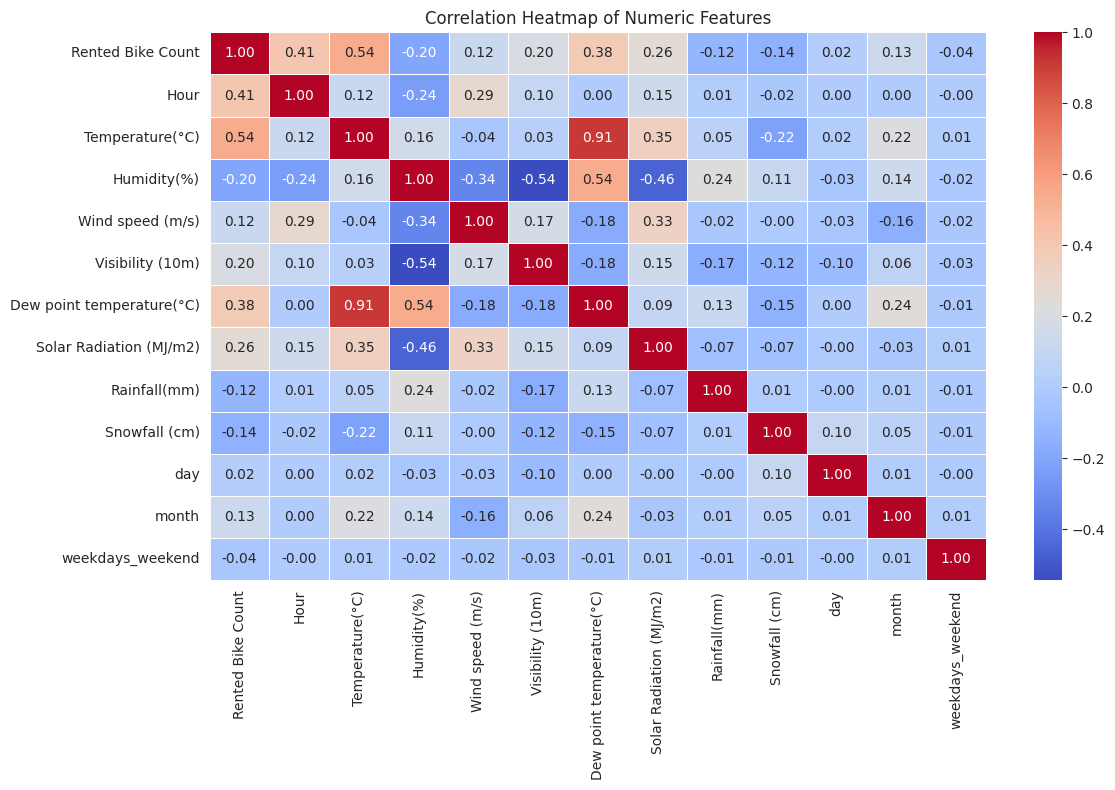

In [7]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

**Inference:** Temperature has the strongest positive correlation with Rented Bike Count (0.54), followed by Hour (0.41) and Dew point temperature (0.38). Temperature and Dew point temperature are highly correlated with each other (0.91), a clear multicollinearity signal and one reason regularized models like Ridge and Lasso are worth comparing against plain Linear Regression. Humidity (-0.20), Snowfall (-0.14), and Rainfall (-0.12) correlate negatively with demand.

## 6. Distribution of Rented Bike Count

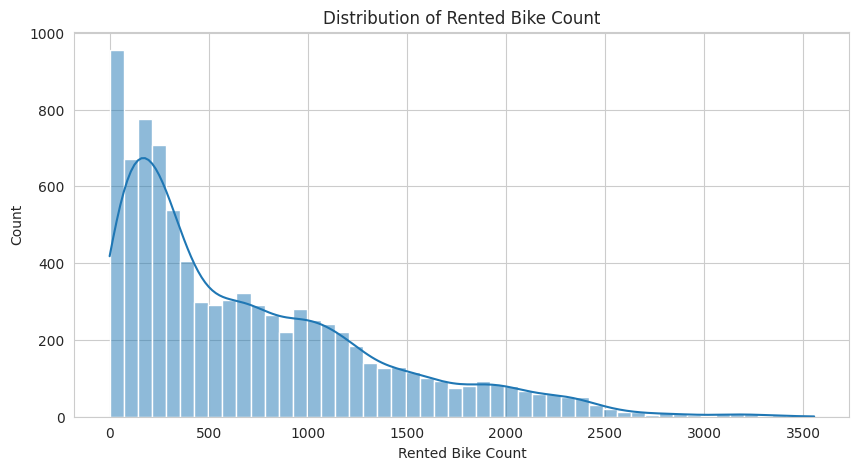

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Rented Bike Count'], kde=True, bins=50)
plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.show()

**Inference:** The target is right-skewed. Most hours have relatively low rental counts, with a long tail of high-demand hours (commute peaks and good-weather days). A skewed target means linear models will tend to under-predict the extreme highs.

## 7. Histograms of All Numerical Features

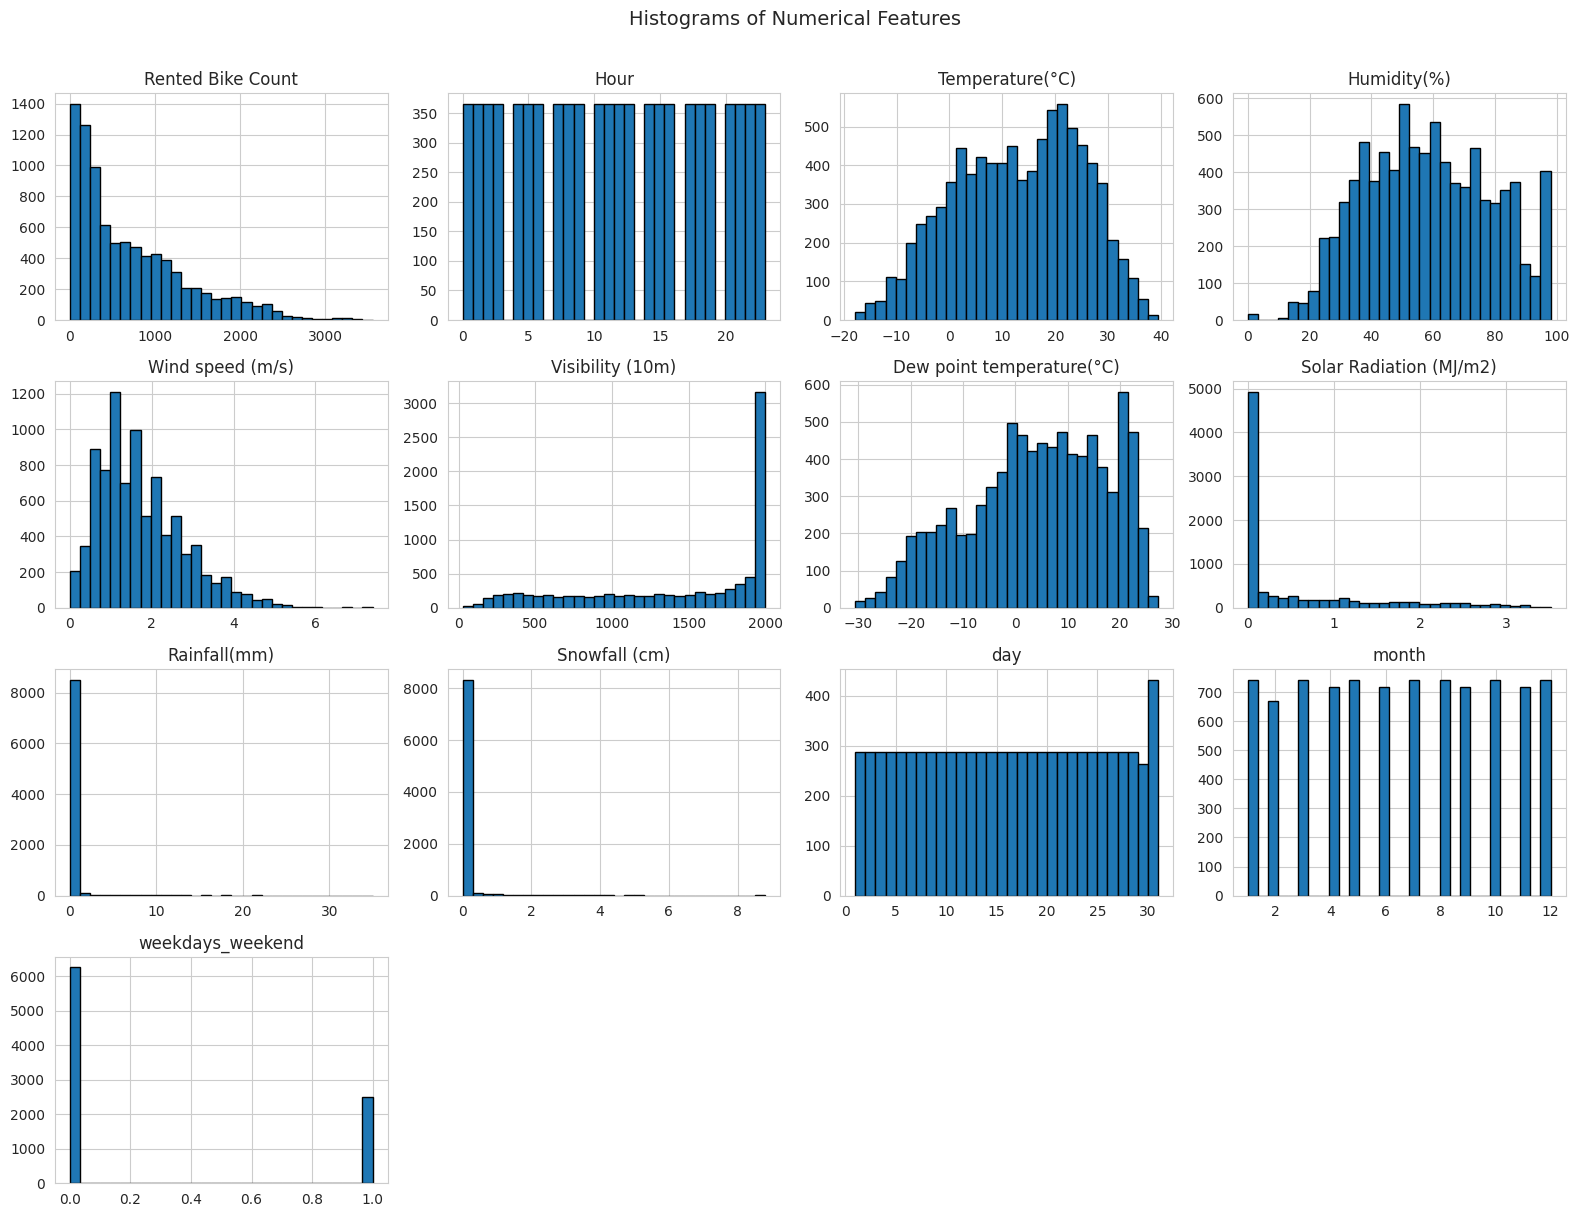

In [9]:
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(16, 12), bins=30, edgecolor='black')
plt.suptitle('Histograms of Numerical Features', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**Inference:** Hour, day, and month are close to uniform, as expected for a full year of hourly records. Rainfall, Snowfall, and Solar Radiation are heavily zero-inflated — most hours have no rain, no snow, and (at night) no solar radiation. Temperature and Humidity are roughly bell-shaped across the year.

## 8. Box Plots of Rented Bike Count vs Categorical Features

Categorical features on the X-axis, Rented Bike Count on the Y-axis.

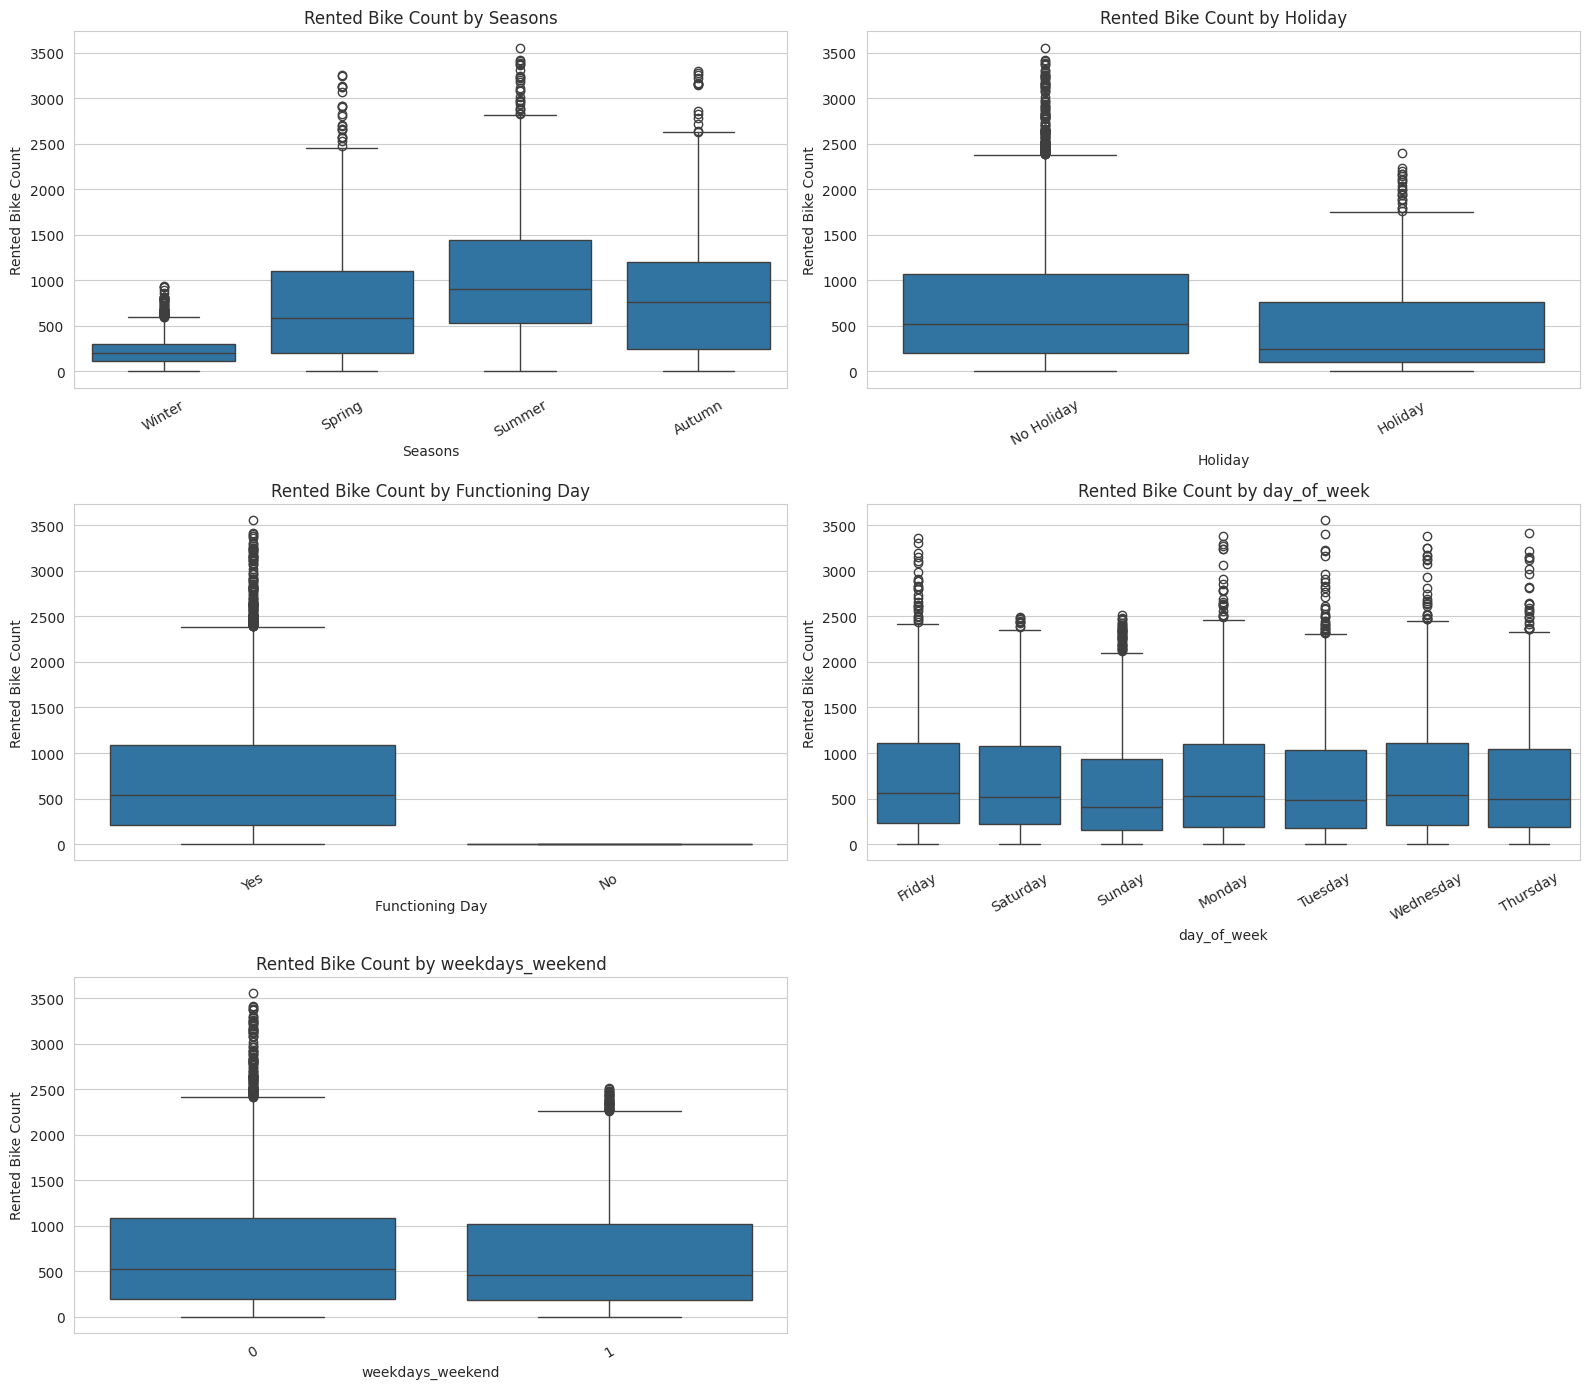

In [10]:
cat_cols = ['Seasons', 'Holiday', 'Functioning Day', 'day_of_week', 'weekdays_weekend']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, x=col, y='Rented Bike Count', ax=axes[i])
    axes[i].set_title(f'Rented Bike Count by {col}')
    axes[i].tick_params(axis='x', rotation=30)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

**Inference:** Demand is highest in Summer and lowest in Winter. Non-holiday days show higher median demand than holidays, consistent with commuting being a major driver. On non-functioning days the rental count is essentially zero — those rows carry no demand signal. Differences across individual weekdays are modest, but weekdays as a group run slightly higher than weekends.

## 9. Catplots of Rented Bike Count vs Key Features

Catplots against Hour, Holiday, Rainfall (mm), Snowfall (cm), and weekdays/weekend.

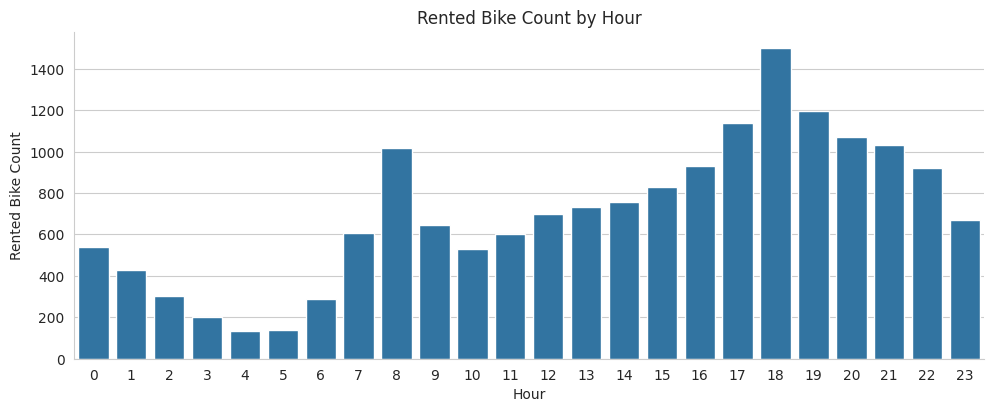

In [11]:
sns.catplot(data=df, x='Hour', y='Rented Bike Count', kind='bar',
            height=4, aspect=2.5, errorbar=None)
plt.title('Rented Bike Count by Hour')
plt.show()

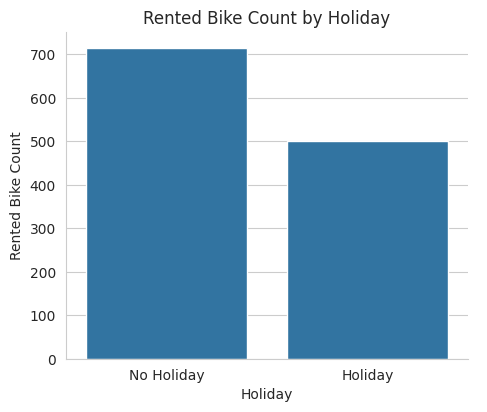

In [12]:
sns.catplot(data=df, x='Holiday', y='Rented Bike Count', kind='bar',
            height=4, aspect=1.2, errorbar=None)
plt.title('Rented Bike Count by Holiday')
plt.show()

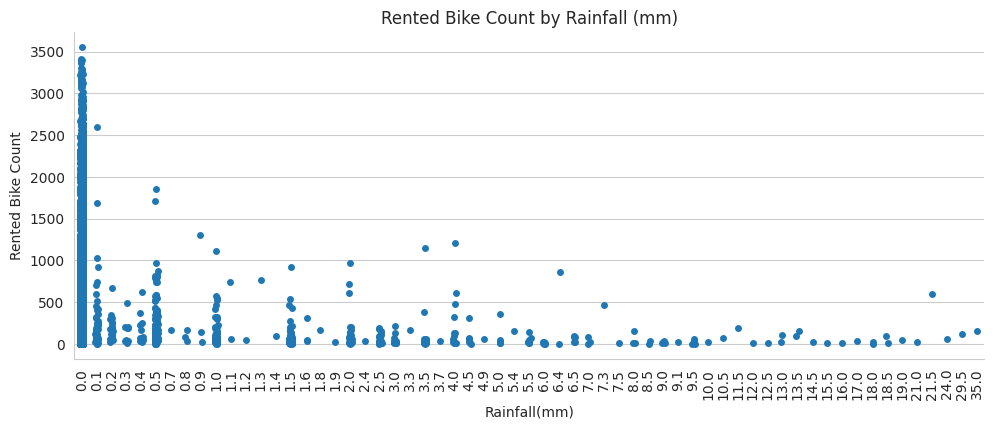

In [13]:
sns.catplot(data=df, x='Rainfall(mm)', y='Rented Bike Count', kind='strip',
            height=4, aspect=2.5)
plt.title('Rented Bike Count by Rainfall (mm)')
plt.xticks(rotation=90)
plt.show()

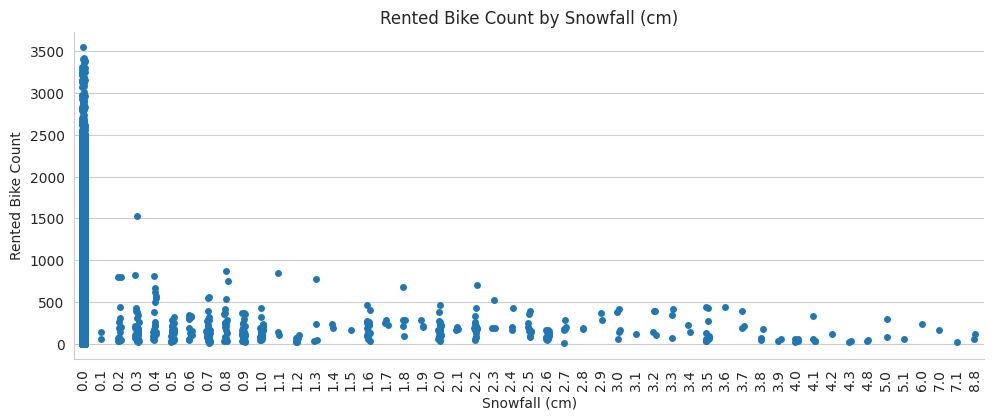

In [14]:
sns.catplot(data=df, x='Snowfall (cm)', y='Rented Bike Count', kind='strip',
            height=4, aspect=2.5)
plt.title('Rented Bike Count by Snowfall (cm)')
plt.xticks(rotation=90)
plt.show()

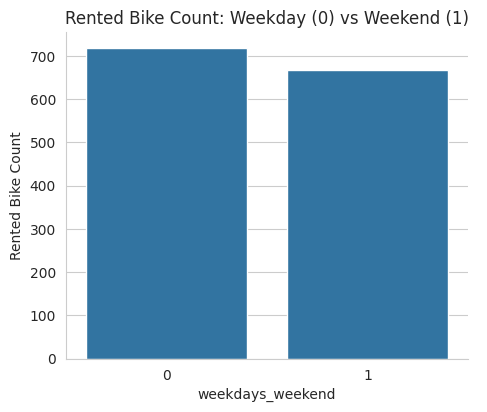

In [15]:
sns.catplot(data=df, x='weekdays_weekend', y='Rented Bike Count', kind='bar',
            height=4, aspect=1.2, errorbar=None)
plt.title('Rented Bike Count: Weekday (0) vs Weekend (1)')
plt.show()

**Inferences:**
- **Hour:** Demand shows two sharp peaks, around 8 AM and 6 PM, matching commute hours. Overnight hours (2–5 AM) have the lowest demand.
- **Holiday:** Average demand is noticeably lower on holidays, again pointing to commuting as the dominant use case.
- **Rainfall:** Demand collapses as soon as there is meaningful rainfall. High rental counts occur almost exclusively at 0 mm.
- **Snowfall:** Same pattern as rainfall — any snowfall suppresses demand sharply.
- **Weekdays vs weekend:** Weekdays (0) average higher demand than weekends (1), consistent with the commute-driven peaks seen in the hourly plot.

## 10. Encode Categorical Features

We one-hot encode the categorical columns with `pd.get_dummies()`. The original `Date` column is dropped since its useful information has already been extracted into day, month, day_of_week, and weekdays_weekend.

In [16]:
df_model = df.drop(columns=['Date'])

df_encoded = pd.get_dummies(
    df_model,
    columns=['Seasons', 'Holiday', 'Functioning Day', 'day_of_week'],
    drop_first=True,
    dtype=int
)

print(df_encoded.shape)
df_encoded.head()

(8760, 24)


,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),...,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,...,0,1,1,1,0,0,0,0,0,0


## 11. Train/Test Split (80:20, random_state=1)

The target variable is **Rented Bike Count**; all remaining columns are features.

In [17]:
X = df_encoded.drop(columns=['Rented Bike Count'])
y = df_encoded['Rented Bike Count']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1
)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (7008, 23), X_test: (1752, 23)


## 12. Standard Scaling

The scaler is fit on the training set only, then applied to both train and test sets — fitting on the full data would leak test-set statistics into training.

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 13. Linear, Lasso, and Ridge Regression

We train all three models and compare them on R², RMSE, and MAE.

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=1.0),
    'Ridge Regression': Ridge(alpha=1.0)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'R2 Score': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    })

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df

,R2 Score,RMSE,MAE
Model,,,
Linear Regression,0.551,430.803,320.359
Lasso Regression,0.551,430.639,320.279
Ridge Regression,0.551,430.787,320.352


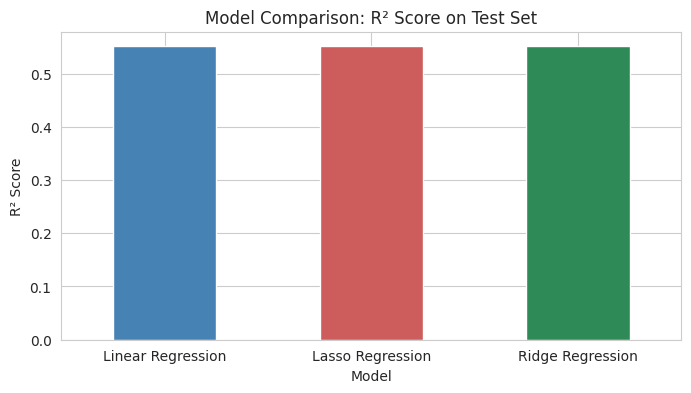

In [20]:
results_df['R2 Score'].plot(kind='bar', figsize=(8, 4), color=['steelblue', 'indianred', 'seagreen'])
plt.title('Model Comparison: R² Score on Test Set')
plt.ylabel('R² Score')
plt.xticks(rotation=0)
plt.show()

## 14. Conclusion

All three models land essentially on top of each other: Lasso edges out the others with R² = 0.5513 (RMSE 430.6, MAE 320.3), against 0.5510 for Ridge and 0.5509 for plain Linear Regression. The differences are in the fourth decimal place, so regularization at default strength barely matters here.

That similarity is informative. Explaining ~55% of the variance is the ceiling for this model class, not a tuning problem: hourly bike demand has strong non-linear structure (the double commute peak, sharp rain/snow thresholds) that no linear model can capture regardless of penalty. Among the three required models, **Lasso Regression is technically the best performer**, though all three are interchangeable in practice. Tree-based ensembles would be the natural next step if higher accuracy were needed.

---

# Task 2: Building an Income Classification Model

**Incremental Capstone — Classification**

The goal is to predict whether a person earns more or less than $50K per year from census attributes. The workflow covers cleaning (including the dataset's "?" placeholder values), univariate and bivariate EDA, label encoding, feature scaling, class-imbalance correction with SMOTE, and a comparison of six classifiers on Accuracy and F1 score.

## 1. Import Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

In [22]:
df = pd.read_csv('data/adultcensusincome.csv')
print(df.shape)
df.head()

(32561, 14)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,Female,0,3900,40,United-States,<=50K


## 3. Check for Null Values and "?" Values

This dataset encodes missing values as the string `"?"` rather than true NaNs, so we check for both. The "?" entries are concentrated in `workclass`, `occupation`, and `native.country`. We replace them with NaN and impute with each column's mode, which preserves all 32,561 rows rather than discarding ~7% of the data.

In [23]:
print('True nulls per column:')
print(df.isnull().sum())
print('\n"?" values per column:')
print((df == '?').sum())

True nulls per column:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

"?" values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [24]:
df = df.replace('?', np.nan)

for col in df.columns[df.isnull().any()]:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Remaining nulls:', df.isnull().sum().sum())

Remaining nulls: 0


## 4. Distribution of the Target Variable

We check whether the two income classes are balanced.

In [25]:
print(df['income'].value_counts())
print('\nProportions:')
print(df['income'].value_counts(normalize=True).round(3))

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Proportions:
income
<=50K    0.759
>50K     0.241
Name: proportion, dtype: float64


**Inference:** The dataset is clearly imbalanced — roughly 76% of records are `<=50K` and only 24% are `>50K`. A model that always predicts `<=50K` would score ~76% accuracy while being useless, which is why we correct the imbalance with SMOTE before modeling and evaluate on F1 as well as accuracy.

## 5. Univariate Analysis

### 5.1 Barplot of income

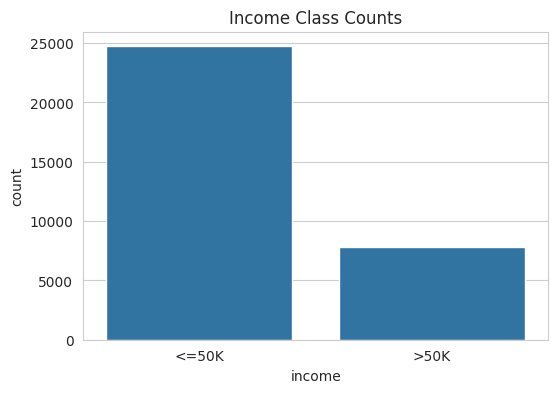

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='income')
plt.title('Income Class Counts')
plt.show()

### 5.2 Distribution plot of age

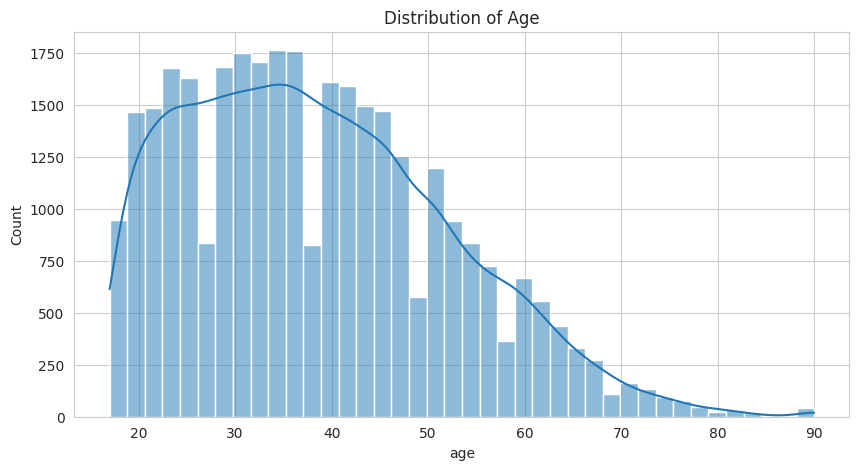

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], kde=True, bins=40)
plt.title('Distribution of Age')
plt.show()

### 5.3 Barplot of education

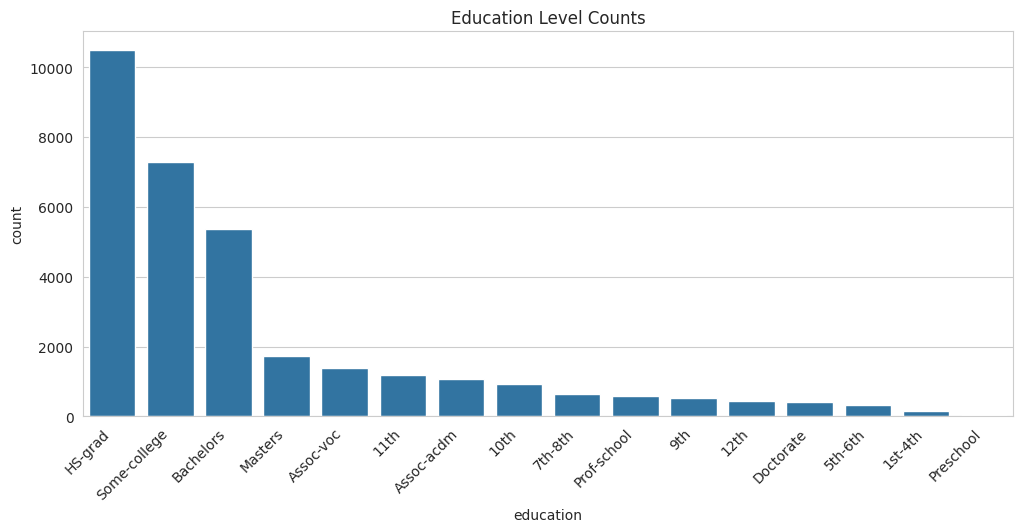

In [28]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='education', order=df['education'].value_counts().index)
plt.title('Education Level Counts')
plt.xticks(rotation=45, ha='right')
plt.show()

### 5.4 Barplot of years of education (education.num)

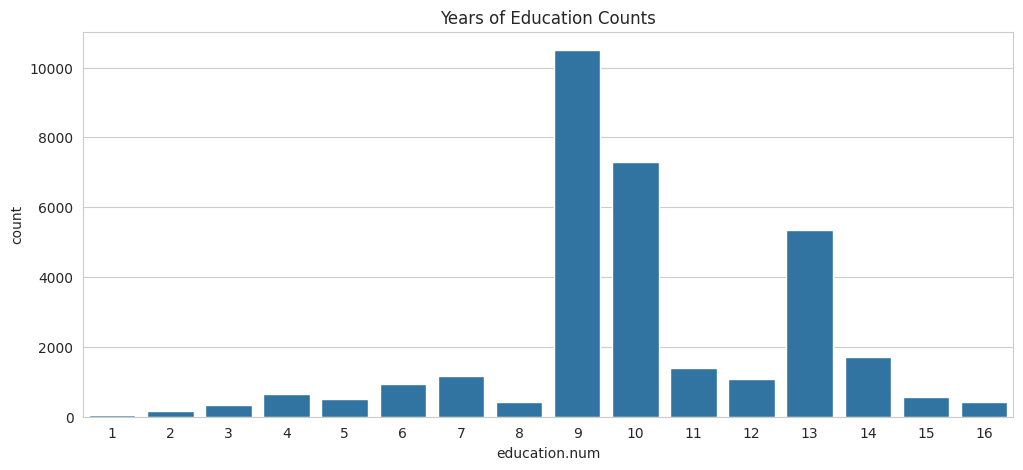

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='education.num')
plt.title('Years of Education Counts')
plt.show()

### 5.5 Pie chart of marital status

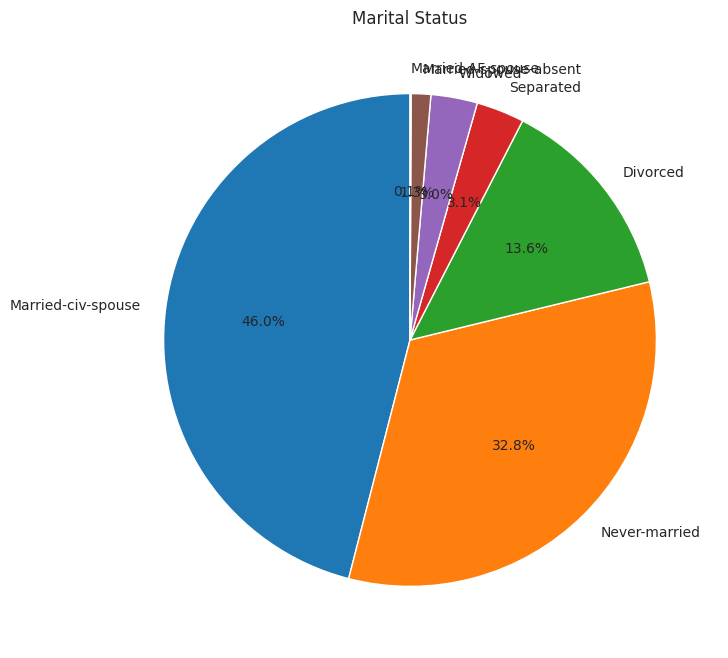

In [30]:
plt.figure(figsize=(8, 8))
df['marital.status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title('Marital Status')
plt.ylabel('')
plt.show()

**Inferences (univariate):** Age is right-skewed with most people between 25 and 50. HS-grad is the most common education level, followed by Some-college and Bachelors; education.num clusters at 9–10 and 13 accordingly. Married-civ-spouse and Never-married together account for roughly two-thirds of the marital status distribution.

## 6. Bivariate Analysis

### 6.1 Countplots of income across age, education, marital status, and sex

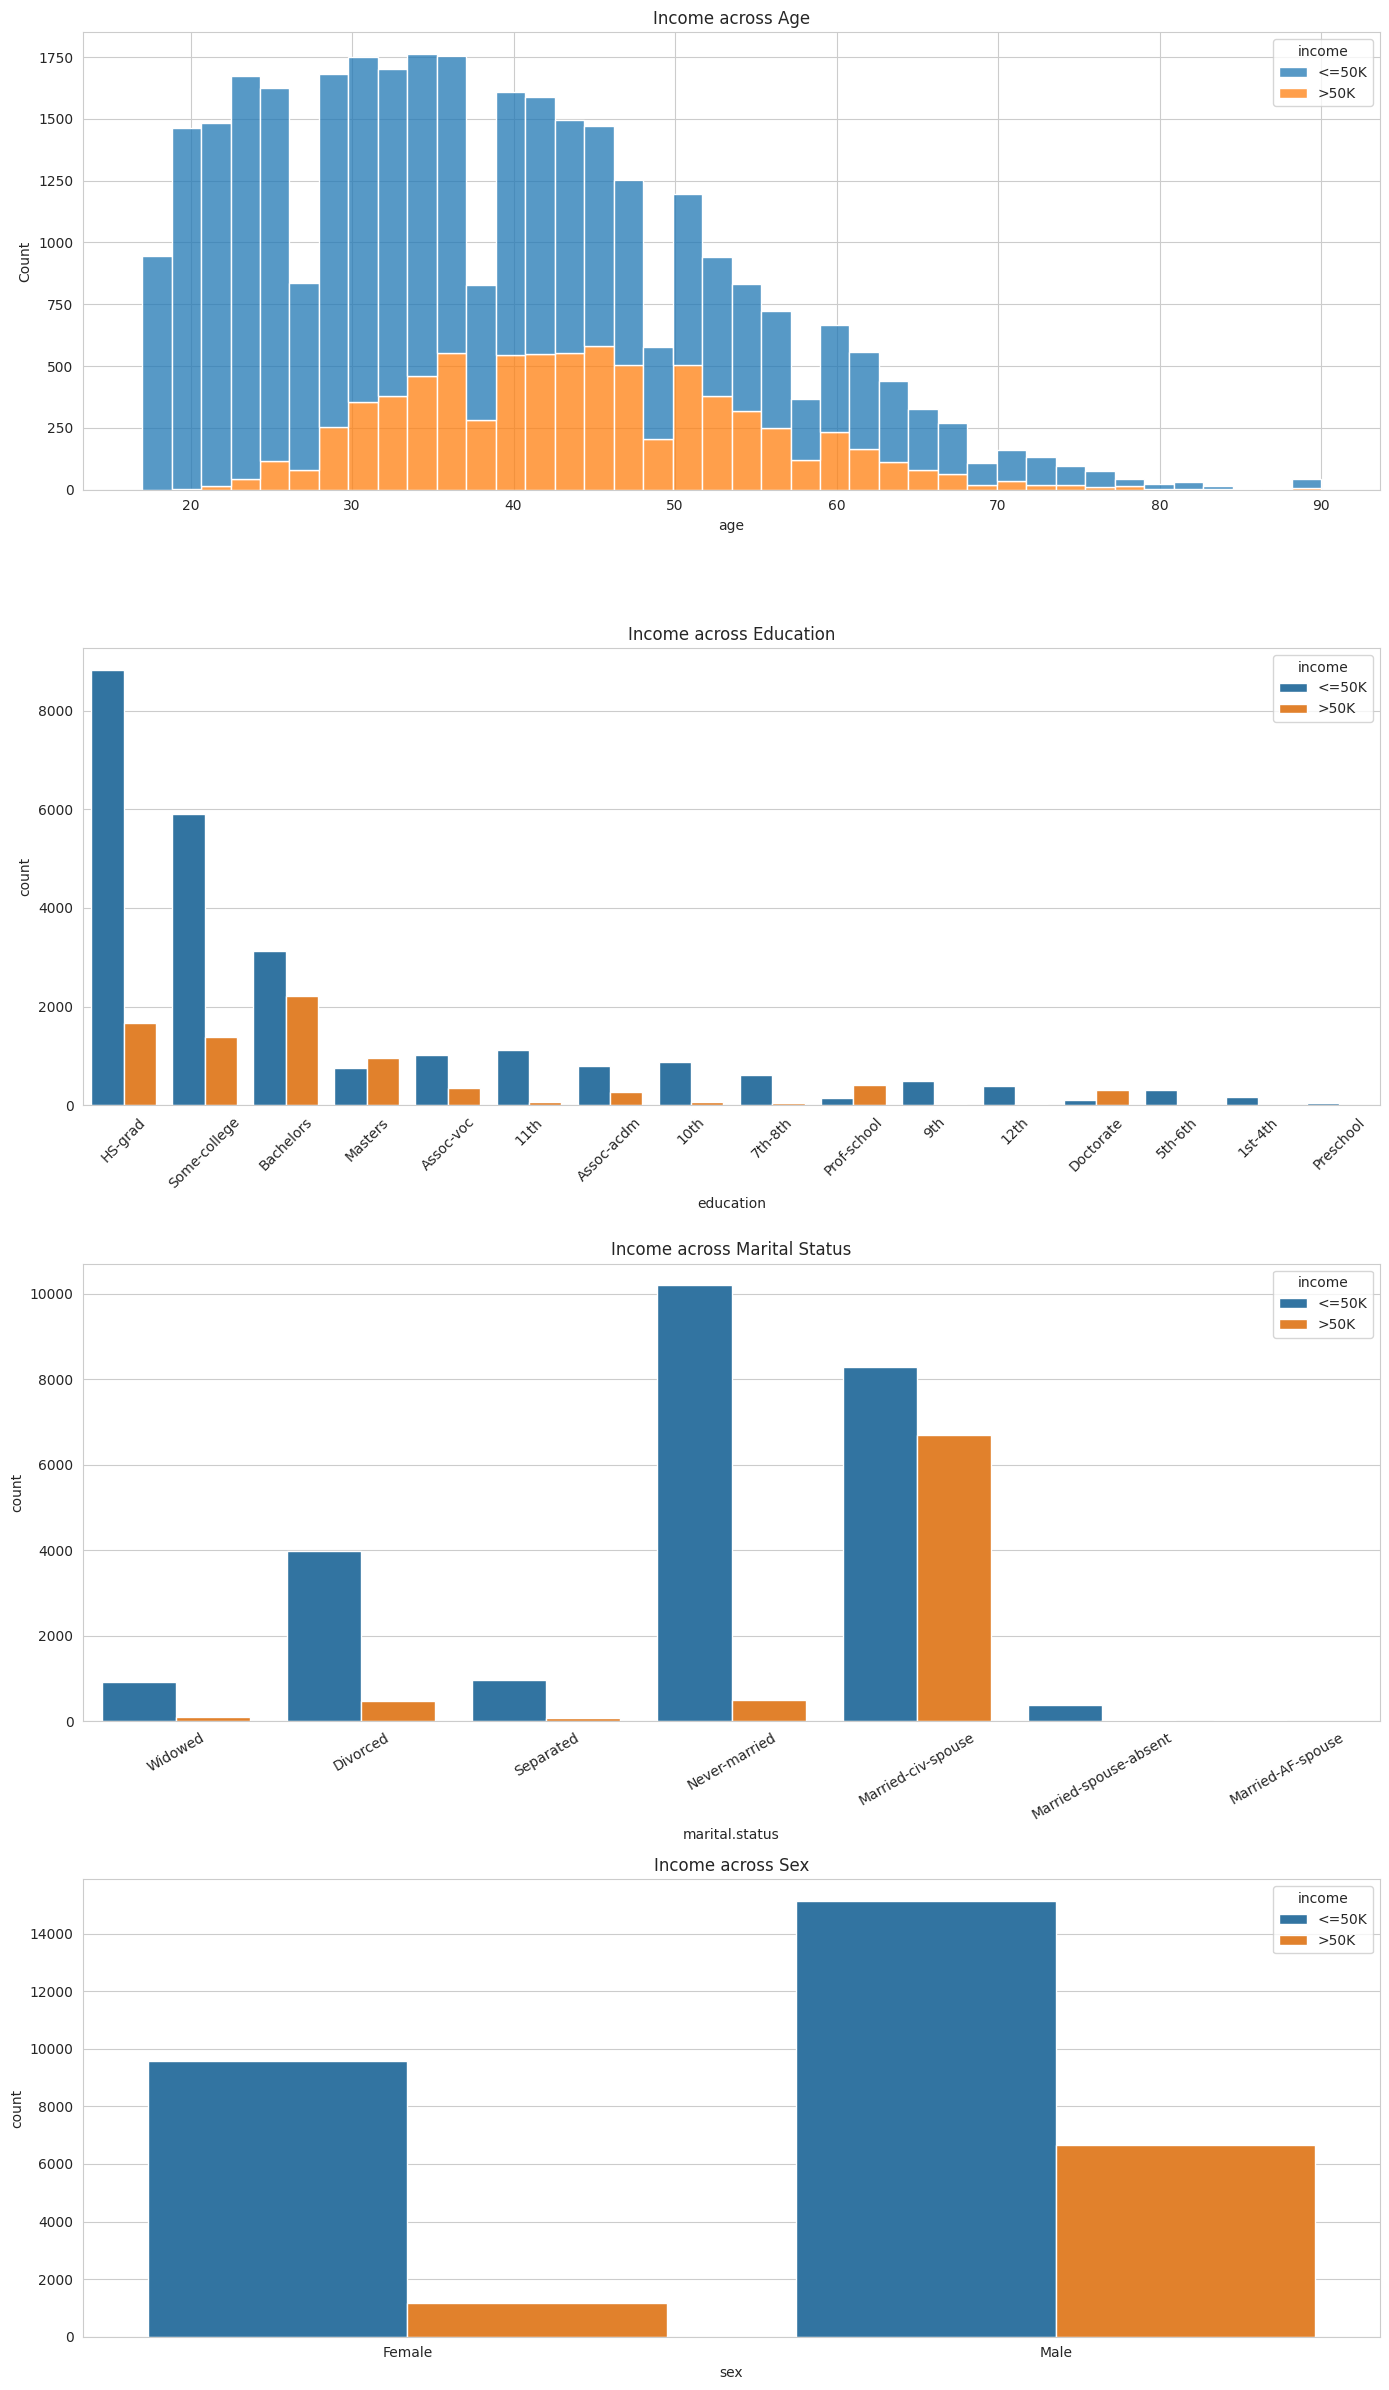

In [31]:
fig, axes = plt.subplots(4, 1, figsize=(14, 24))

sns.histplot(data=df, x='age', hue='income', multiple='stack', bins=40, ax=axes[0])
axes[0].set_title('Income across Age')

sns.countplot(data=df, x='education', hue='income', ax=axes[1],
              order=df['education'].value_counts().index)
axes[1].set_title('Income across Education')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='marital.status', hue='income', ax=axes[2])
axes[2].set_title('Income across Marital Status')
axes[2].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x='sex', hue='income', ax=axes[3])
axes[3].set_title('Income across Sex')

plt.tight_layout()
plt.show()

### 6.2 Correlation heatmap

To compute a full correlation matrix we need everything numeric, so we label encode a copy of the data first, then check which columns income correlates with most strongly.

/tmp/ipykernel_741/2441197943.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include='object').columns:


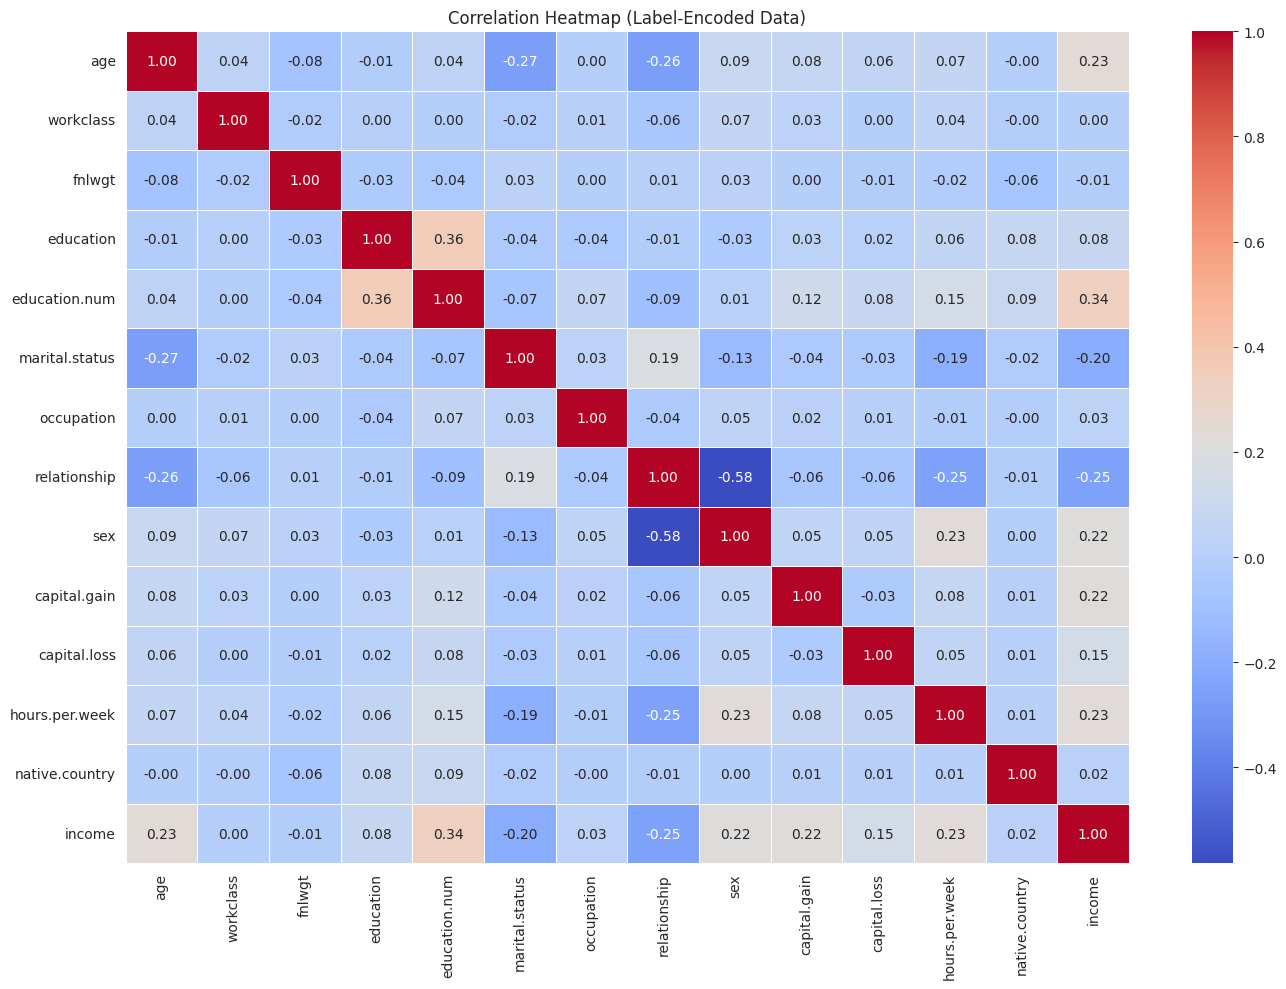

Correlation with income (absolute, descending):
education.num     0.335
relationship      0.251
age               0.234
hours.per.week    0.230
capital.gain      0.223
sex               0.216
marital.status    0.199
capital.loss      0.151
education         0.079
occupation        0.035
native.country    0.023
fnlwgt            0.009
workclass         0.003
Name: income, dtype: float64


In [32]:
df_corr = df.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

plt.figure(figsize=(14, 10))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Label-Encoded Data)')
plt.tight_layout()
plt.show()

print('Correlation with income (absolute, descending):')
print(df_corr.corr()['income'].drop('income').abs().sort_values(ascending=False).round(3))

**Inferences (bivariate):** The share of `>50K` earners rises sharply with education (Bachelors, Masters, Prof-school, Doctorate) and peaks in the 35–55 age band. Married-civ-spouse individuals are far more likely to earn `>50K` than never-married ones, and males show a higher `>50K` proportion than females in this data. The heatmap confirms income is most correlated with **education.num, age, hours.per.week, capital.gain, and sex**, with marital status also carrying signal (its label-encoded correlation is negative purely because of alphabetical category ordering).

## 7. Prepare the Dataset for Modeling

### 7.1 Label encode all categorical columns

In [33]:
df_model = df.copy()
label_encoders = {}
for col in df_model.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

df_model.head()

/tmp/ipykernel_741/358714385.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_model.select_dtypes(include='object').columns:


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,3,77053,11,9,6,9,1,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,0,0,4356,18,38,0
2,66,3,186061,15,10,6,9,4,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,0,0,3900,40,38,0


### 7.2 Independent variables X and dependent variable Y

In [34]:
X = df_model.drop(columns=['income'])
Y = df_model['income']
print(f'X: {X.shape}, Y: {Y.shape}')

X: (32561, 13), Y: (32561,)


### 7.3 Feature scaling and fixing the imbalance with SMOTE

SMOTE synthesizes new minority-class samples by interpolating between existing minority neighbors, giving the classifiers a balanced training signal instead of one dominated by `<=50K`.

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before SMOTE:', np.bincount(Y))
smote = SMOTE(random_state=42)
X_resampled, Y_resampled = smote.fit_resample(X_scaled, Y)
print('After SMOTE: ', np.bincount(Y_resampled))

Before SMOTE: [24720  7841]


After SMOTE:  [24720 24720]


### 7.4 Train/test split (80:20, random_state=42)

In [36]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_resampled, Y_resampled, test_size=0.20, random_state=42
)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

X_train: (39552, 13), X_test: (9888, 13)


## 8. Data Modeling

We train six classifiers and evaluate each on Accuracy and F1 score. (The SVM is the slowest of the six — expect that cell to take a few minutes on ~40K training rows.)

In [37]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN Classifier': KNeighborsClassifier(),
    'SVM Classifier': SVC(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, Y_train)
    Y_pred = model.predict(X_test)
    acc = accuracy_score(Y_test, Y_pred)
    f1 = f1_score(Y_test, Y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})
    print(f'{name:<22} Accuracy: {acc:.4f}   F1: {f1:.4f}')

Logistic Regression    Accuracy: 0.7669   F1: 0.7657


KNN Classifier         Accuracy: 0.8535   F1: 0.8631


SVM Classifier         Accuracy: 0.8303   F1: 0.8391
Naive Bayes            Accuracy: 0.6941   F1: 0.5986


Decision Tree          Accuracy: 0.8522   F1: 0.8522


Random Forest          Accuracy: 0.8986   F1: 0.8994


In [38]:
results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df.sort_values('F1 Score', ascending=False)

,Accuracy,F1 Score
Model,,
Random Forest,0.8986,0.8994
KNN Classifier,0.8535,0.8631
Decision Tree,0.8522,0.8522
SVM Classifier,0.8303,0.8391
Logistic Regression,0.7669,0.7657
Naive Bayes,0.6941,0.5986


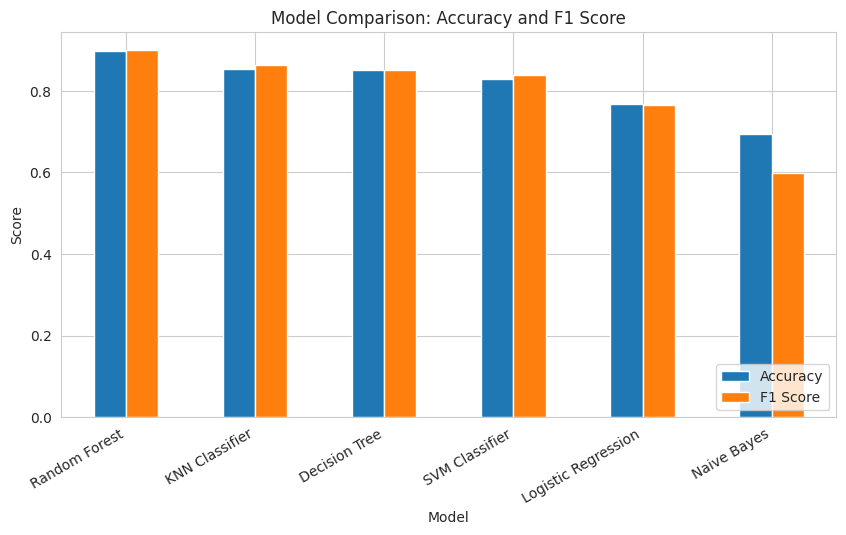

In [39]:
results_df.sort_values('F1 Score', ascending=False).plot(
    kind='bar', figsize=(10, 5)
)
plt.title('Model Comparison: Accuracy and F1 Score')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.show()

## 9. Conclusion

The target was imbalanced (75.9% `<=50K` vs 24.1% `>50K`), so SMOTE was applied to balance the classes (24,720 samples each) before the 80:20 split. Six classifiers were then compared on the balanced data:

**Random Forest is the best model, with 0.8986 accuracy and 0.8994 F1** — comfortably ahead of the rest. KNN (0.8535 / 0.8631) and Decision Tree (0.8522 / 0.8522) form the next tier, with SVM close behind (0.8303 / 0.8391). Logistic Regression (0.7669 / 0.7657) is limited by the non-linear feature interactions in this data, and Naive Bayes trails badly (0.6941 accuracy, 0.5986 F1) because its feature-independence assumption is strongly violated — age, education, marital status, and hours worked are all interrelated.

The pattern is consistent with the EDA: income depends on interactions (education *and* age *and* hours), which tree ensembles capture naturally. Random Forest's near-identical accuracy and F1 also indicate balanced performance across both classes rather than majority-class bias.

---

# Task 3: Clustering Credit Card Users with PCA and K-Means

**Incremental Capstone — Unsupervised Learning**

This task segments ~9,000 credit card holders by usage behavior. We scale the features, use PCA both to measure how many components capture 85% of the variance and to project the data to 2D, then run K-Means with the elbow method to pick a cluster count and visualize the resulting customer segments.

## 1. Import Libraries

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Dataset

In [41]:
df = pd.read_csv('data/CC_GENERAL.csv')
print(df.shape)
df.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 3. Check for Null Values and Handle Them

`CREDIT_LIMIT` and `MINIMUM_PAYMENTS` contain missing values. Both are heavily right-skewed dollar amounts, so we impute with the **median**, which is robust to the extreme values. `CUST_ID` is a customer identifier with no behavioral meaning, so we drop it before analysis.

In [42]:
print(df.isnull().sum()[df.isnull().sum() > 0])

df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

df = df.drop(columns=['CUST_ID'])
print('\nRemaining nulls:', df.isnull().sum().sum())

CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Remaining nulls: 0


## 4. Feature Scaling

PCA and K-Means are both distance-based, so unscaled dollar columns (BALANCE, PURCHASES) would dominate frequency columns that live between 0 and 1. StandardScaler puts every feature on equal footing.

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled.shape

(8950, 17)

## 5. PCA with All Components: Cumulative Explained Variance

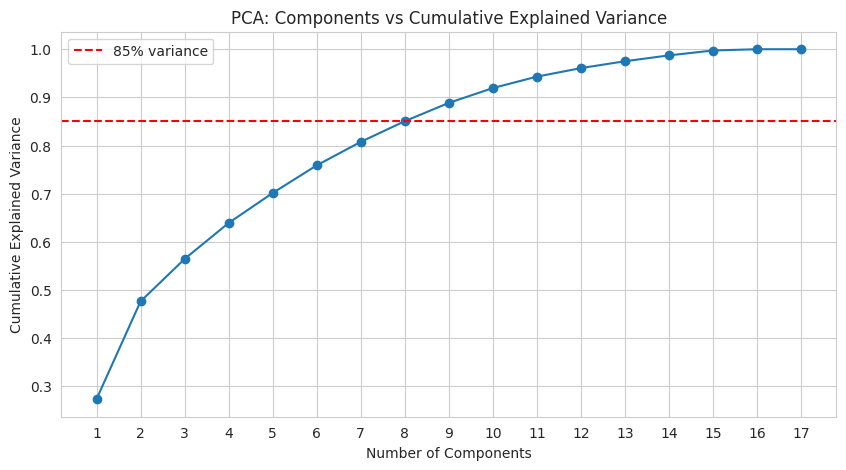

In [44]:
pca_full = PCA()
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(y=0.85, color='red', linestyle='--', label='85% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Components vs Cumulative Explained Variance')
plt.xticks(range(1, len(cum_var) + 1))
plt.legend()
plt.show()

## 6. Components Required for 85% of the Variance

In [45]:
n_components_85 = int(np.argmax(cum_var >= 0.85) + 1)
print(f'Components required to cover 85% of the variance: {n_components_85}')
print(f'Cumulative variance at that point: {cum_var[n_components_85 - 1]:.4f}')

Components required to cover 85% of the variance: 8
Cumulative variance at that point: 0.8505


**Inference:** **8 components** are required to cover 85% of the variance (cumulative variance = 0.8505 at 8 components). The curve rises steeply through the first four components and flattens after eight, meaning the 17 original behavioral features carry substantial redundancy — about half the dimensions can be discarded while keeping 85% of the information.

## 7. PCA with 2 Principal Components (for Cluster Visualization)

In [46]:
pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)

print('Explained variance ratio of the 2 components:', pca_2.explained_variance_ratio_.round(4))
print('Total variance captured in 2D:', pca_2.explained_variance_ratio_.sum().round(4))

Explained variance ratio of the 2 components: [0.273  0.2031]
Total variance captured in 2D: 0.4761


## 8. Two Columns with the Most Covariance

We inspect the covariance matrix reconstructed by the 2-component PCA via `get_covariance()`. The largest off-diagonal entry identifies the pair of original features that vary together most strongly.

Highest covariance pair: PURCHASES  <->  PURCHASES_TRX
Covariance: 0.6483


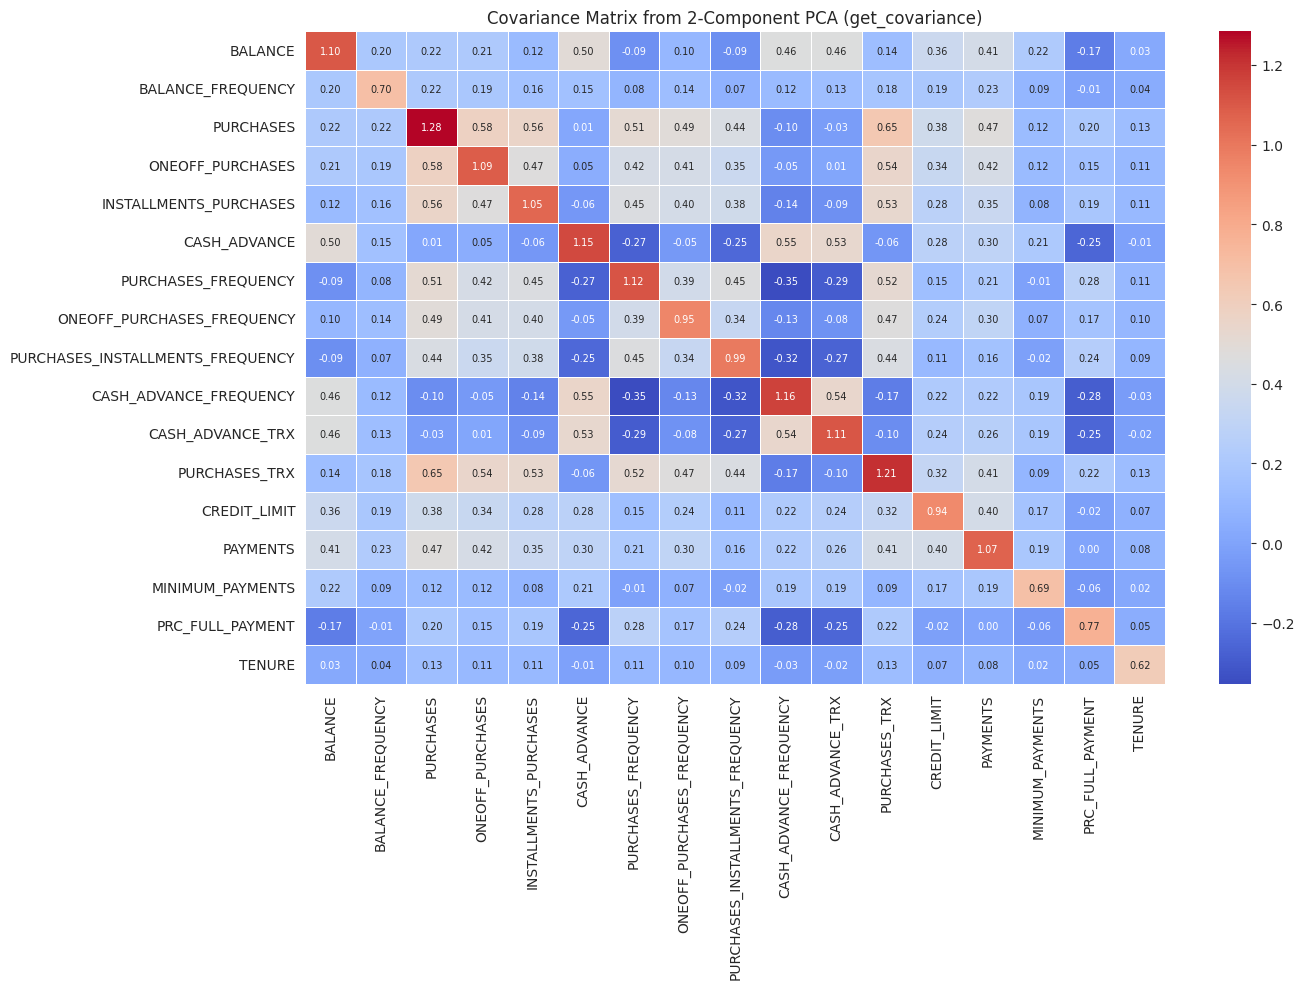

In [47]:
cov_matrix = pd.DataFrame(pca_2.get_covariance(), index=df.columns, columns=df.columns)

# largest off-diagonal covariance
cov_offdiag = cov_matrix.where(~np.eye(len(cov_matrix), dtype=bool))
max_pair = cov_offdiag.stack().idxmax()
print(f'Highest covariance pair: {max_pair[0]}  <->  {max_pair[1]}')
print(f'Covariance: {cov_offdiag.stack().max():.4f}')

plt.figure(figsize=(14, 10))
sns.heatmap(cov_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5,
            annot_kws={'size': 7})
plt.title('Covariance Matrix from 2-Component PCA (get_covariance)')
plt.tight_layout()
plt.show()

**Interpretation of the PCA covariance matrix:** The two columns with the highest covariance are **PURCHASES and PURCHASES_TRX** (covariance 0.648) — total purchase amount moves almost in lockstep with the number of purchase transactions, which is intuitive. More broadly, the covariance matrix splits the features into two behavioral blocks: a *purchasing* block (PURCHASES, ONEOFF_PURCHASES, INSTALLMENTS_PURCHASES, PURCHASES_TRX, and the purchase frequency columns all co-vary positively) and a *cash-advance/balance* block (CASH_ADVANCE, CASH_ADVANCE_TRX, CASH_ADVANCE_FREQUENCY, BALANCE). The two blocks covary weakly with each other, which is exactly why the first two principal components separate "spenders" from "cash-advance revolvers." Note the 2D projection captures 47.6% of total variance — enough to visualize structure, but the full segmentation signal needs the 8 components found above.

## 9. K-Means Clustering

### 9.1 Elbow method: inertia for k = 2 to 11

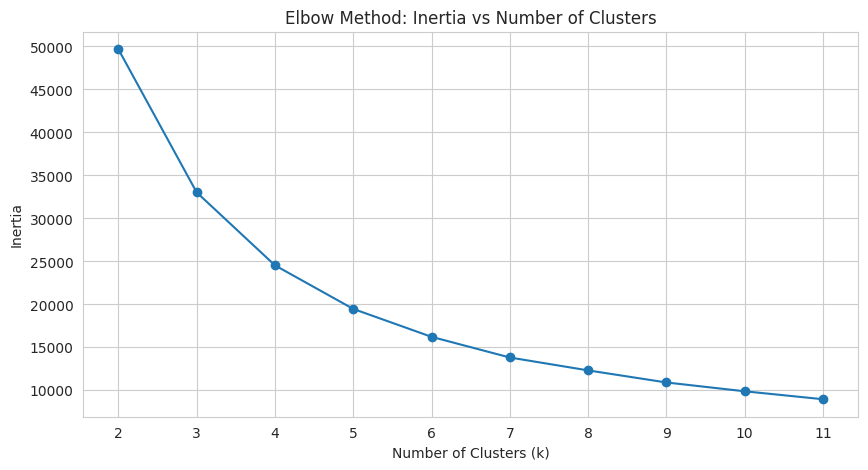

In [48]:
inertias = []
k_range = range(2, 12)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca2)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method: Inertia vs Number of Clusters')
plt.xticks(list(k_range))
plt.show()

**Inference:** Inertia falls from ~49.7K at k=2 to ~33.0K at k=3 and ~24.5K at k=4, but the improvements shrink sharply after that (~19.5K at k=5, ~16.2K at k=6). The bend in the curve sits at **k=4**, so 4 is the ideal number of clusters.

### 9.2 K-Means with the ideal number of clusters

In [49]:
ideal_k = 4  # chosen from the elbow plot above
kmeans = KMeans(n_clusters=ideal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca2)
print('Cluster sizes:', np.bincount(cluster_labels))

Cluster sizes: [3918 3284 1246  502]


### 9.3 Visualize the clusters on the 2D PCA projection

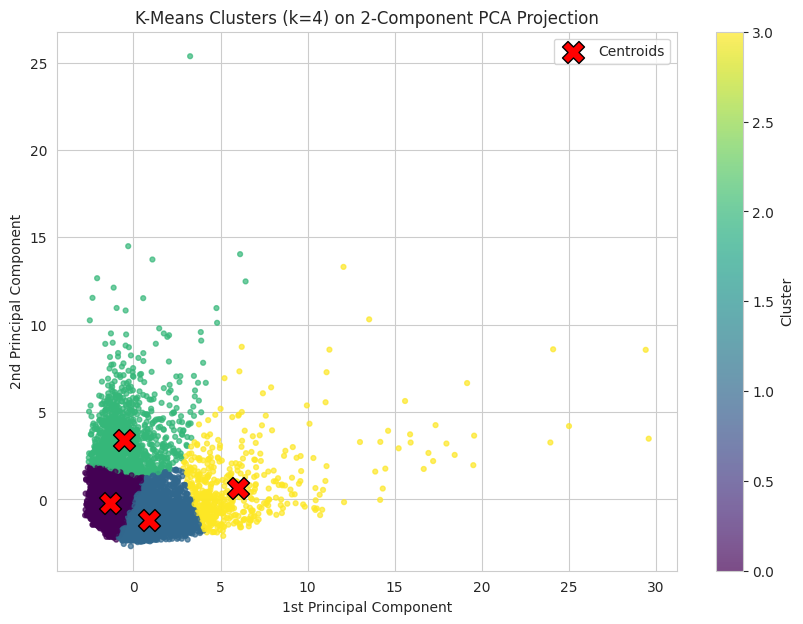

In [50]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=cluster_labels,
                      cmap='viridis', s=12, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=250, edgecolors='black', label='Centroids')
plt.xlabel('1st Principal Component')
plt.ylabel('2nd Principal Component')
plt.title(f'K-Means Clusters (k={ideal_k}) on 2-Component PCA Projection')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.show()

## 10. Conclusion

Scaling followed by PCA showed that 8 of the 17 behavioral features' worth of variance (85%) is enough to describe these cardholders, and the 2-component projection (47.6% of variance) is sufficient to see the cluster structure. The elbow method pointed to **k=4**, and K-Means produced four segments of 3,918 / 3,284 / 1,246 / 502 customers.

Reading the clusters against the PCA axes: the two large clusters near the origin are low-activity cardholders (low balances, few purchases) split by modest differences in usage style; the mid-sized cluster extends along the purchasing direction (frequent, higher-volume purchasers); and the small 502-customer cluster sits far out along the balance/cash-advance direction — heavy revolvers who carry large balances and take cash advances. From a business standpoint these four segments suggest different treatments: activation campaigns for the low-activity majority, rewards and credit-line increases for the active purchasers, and risk monitoring for the cash-advance-heavy group.

---

# Task 4: Movie Recommendation Techniques

**Incremental Capstone — Recommendation Systems**

This task builds movie recommendations from the MovieLens ratings data three different ways:

1. **User-based collaborative filtering** — find users who rate like User 1 and use their ratings to predict what User 1 would think of an unseen movie.
2. **Item-based collaborative filtering** — find movies whose rating patterns resemble *Jurassic Park (1993)* and recommend the most similar ones.
3. **Model-based collaborative filtering** — use the Surprise library to cross-validate KNNBasic, SVD, and NMF and compare them on RMSE.

## 1. Import Libraries

In [51]:
import numpy as np
import pandas as pd

from surprise import Dataset, Reader, KNNBasic, SVD, NMF
from surprise.model_selection import cross_validate

## 2. Load and Merge the Datasets

We load `movies.csv` and `ratings.csv` and merge them on `movieId` so every rating row carries the movie title.

In [52]:
movies = pd.read_csv('data/movies.csv')
ratings = pd.read_csv('data/ratings.csv')

print(f'movies: {movies.shape}, ratings: {ratings.shape}')
movies.head()

movies: (9742, 3), ratings: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [53]:
df = pd.merge(ratings, movies, on='movieId')
print(df.shape)
df.head()

(100836, 6)


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


## 3. Create the User-Item Matrix

Rows are users, columns are movie titles, values are ratings. Movies a user has not rated appear as NaN — the matrix is very sparse, which is the core challenge of collaborative filtering.

In [54]:
user_item = df.pivot_table(index='userId', columns='title', values='rating')
print(user_item.shape)
user_item.iloc[:5, :5]

(610, 9719)


title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997)
userId,,,,,
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN


## 4. User-based Collaborative Filtering

### 4.1 Fill row-wise NaNs with each user's mean rating

Filling with the user's own mean keeps that user's rating scale intact (a generous rater's blanks become generous, a harsh rater's blanks become harsh) so the correlations that follow measure *taste*, not rating-scale differences.

In [55]:
user_item_user_filled = user_item.apply(lambda row: row.fillna(row.mean()), axis=1)
user_item_user_filled.iloc[:5, :5]

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997)
userId,,,,,
1,4.366379,4.366379,4.366379,4.366379,4.366379
2,3.948276,3.948276,3.948276,3.948276,3.948276
3,2.435897,2.435897,2.435897,2.435897,2.435897
4,3.555556,3.555556,3.555556,3.555556,3.555556
5,3.636364,3.636364,3.636364,3.636364,3.636364


### 4.2 Pearson correlation between users

`DataFrame.corr()` correlates columns, so we transpose first to make each user a column.

In [56]:
user_corr = user_item_user_filled.T.corr(method='pearson')
user_corr.iloc[:5, :5]

userId,1,2,3,4,5
userId,,,,,
1,1.000000,1.264516e-03,5.525772e-04,0.048419,0.021847
2,0.001265,1.000000e+00,-4.975816e-17,-0.017164,0.021796
3,0.000553,-4.975816e-17,1.000000e+00,-0.011260,-0.031539
4,0.048419,-1.716402e-02,-1.125978e-02,1.000000,-0.029620
5,0.021847,2.179571e-02,-3.153892e-02,-0.029620,1.000000


### 4.3 Correlation of all users with User 1, sorted descending, NaNs dropped

In [57]:
user1_corr = user_corr[1].sort_values(ascending=False).dropna()
user1_corr.head(10)

userId
1      1.000000
301    0.124799
597    0.102631
414    0.101348
477    0.099217
57     0.099070
369    0.098295
206    0.096852
535    0.096493
590    0.095191
Name: 1, dtype: float64

### 4.4 Top 50 users most correlated with User 1

We exclude User 1's self-correlation (always 1.0) before taking the top 50.

In [58]:
top50_users = user1_corr.drop(index=1).head(50)
top50_users.head(10)

userId
301    0.124799
597    0.102631
414    0.101348
477    0.099217
57     0.099070
369    0.098295
206    0.096852
535    0.096493
590    0.095191
418    0.094153
Name: 1, dtype: float64

### 4.5 Predict User 1's rating for movieId 32

The prediction is a weighted average of the top-50 neighbors' ratings for the movie, weighted by their correlation with User 1:

$$\hat{r} = \frac{\sum_i (w_i \times r_i)}{\sum_i w_i}$$

In [59]:
movie_32_title = movies.loc[movies['movieId'] == 32, 'title'].values[0]
print(f'movieId 32 = {movie_32_title}')

neighbor_ratings = user_item_user_filled.loc[top50_users.index, movie_32_title]
weights = top50_users

predicted_rating = (weights * neighbor_ratings).sum() / weights.sum()
print(f'Predicted rating for User 1 on movieId 32: {predicted_rating:.3f}')

movieId 32 = Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
Predicted rating for User 1 on movieId 32: 3.845


## 5. Item-based Collaborative Filtering

### 5.1 Fill column-wise NaNs with each movie's mean rating

This time each movie's missing ratings are filled with that movie's average, so the correlations that follow compare movies on how users collectively rate them.

In [60]:
user_item_movie_filled = user_item.fillna(user_item.mean(axis=0))
user_item_movie_filled.iloc[:5, :5]

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997)
userId,,,,,
1,4.0,4.0,3.5,5.0,4.0
2,4.0,4.0,3.5,5.0,4.0
3,4.0,4.0,3.5,5.0,4.0
4,4.0,4.0,3.5,5.0,4.0
5,4.0,4.0,3.5,5.0,4.0


### 5.2 Pearson correlation between movies, focused on Jurassic Park (1993)

In [61]:
jp_ratings = user_item_movie_filled['Jurassic Park (1993)']
jp_corr = user_item_movie_filled.corrwith(jp_ratings, method='pearson')
jp_corr = jp_corr.sort_values(ascending=False).dropna()
jp_corr.head(10)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


title
Jurassic Park (1993)                           1.000000
Fugitive, The (1993)                           0.324717
Lethal Weapon (1987)                           0.318646
Independence Day (a.k.a. ID4) (1996)           0.263629
Mission: Impossible (1996)                     0.258080
Ghostbusters (a.k.a. Ghost Busters) (1984)     0.256527
Mulan (1998)                                   0.255672
Rise of the Planet of the Apes (2011)          0.248134
Bug's Life, A (1998)                           0.240964
Indiana Jones and the Temple of Doom (1984)    0.239826
dtype: float64

### 5.3 Ten movies most similar to Jurassic Park (1993)

We drop Jurassic Park's self-correlation and take the top 10.

In [62]:
similar_to_jp = jp_corr.drop(index='Jurassic Park (1993)').head(10)
similar_to_jp

title
Fugitive, The (1993)                           0.324717
Lethal Weapon (1987)                           0.318646
Independence Day (a.k.a. ID4) (1996)           0.263629
Mission: Impossible (1996)                     0.258080
Ghostbusters (a.k.a. Ghost Busters) (1984)     0.256527
Mulan (1998)                                   0.255672
Rise of the Planet of the Apes (2011)          0.248134
Bug's Life, A (1998)                           0.240964
Indiana Jones and the Temple of Doom (1984)    0.239826
Die Hard (1988)                                0.239294
dtype: float64

## 6. Model-based Collaborative Filtering with Surprise

We load the raw ratings into Surprise and cross-validate three models with 5 folds against RMSE:

- **KNNBasic** with Mean Squared Distance similarity and 20 neighbors
- **SVD** (matrix factorization)
- **NMF** (non-negative matrix factorization)

In [63]:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

In [64]:
sim_options = {'name': 'msd', 'user_based': True}
knn = KNNBasic(k=20, sim_options=sim_options)
knn_results = cross_validate(knn, data, measures=['RMSE'], cv=5, verbose=True)

Computing the msd similarity matrix...
Done computing similarity matrix.


Computing the msd similarity matrix...
Done computing similarity matrix.


Computing the msd similarity matrix...
Done computing similarity matrix.


Computing the msd similarity matrix...
Done computing similarity matrix.


Computing the msd similarity matrix...
Done computing similarity matrix.


Evaluating RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9400  0.9498  0.9441  0.9396  0.9359  0.9419  0.0047  
Fit time          0.10    0.10    0.11    0.11    0.10    0.10    0.01    
Test time         0.93    1.01    0.94    0.91    0.90    0.94    0.04    


In [65]:
svd = SVD()
svd_results = cross_validate(svd, data, measures=['RMSE'], cv=5, verbose=True)

Evaluating RMSE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8665  0.8775  0.8720  0.8758  0.8724  0.8728  0.0038  
Fit time          0.98    1.06    1.01    1.03    1.03    1.02    0.03    
Test time         0.23    0.12    0.12    0.11    0.24    0.16    0.06    


In [66]:
nmf = NMF()
nmf_results = cross_validate(nmf, data, measures=['RMSE'], cv=5, verbose=True)

Evaluating RMSE of algorithm NMF on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9135  0.9198  0.9268  0.9260  0.9276  0.9228  0.0054  
Fit time          2.31    2.53    2.34    2.41    2.31    2.38    0.08    
Test time         0.10    0.08    0.08    0.09    0.22    0.11    0.05    


### 6.1 Best scores and parameters from cross-validation

In [67]:
summary = pd.DataFrame({
    'Model': ['KNNBasic (msd, k=20)', 'SVD', 'NMF'],
    'Best RMSE (min fold)': [
        knn_results['test_rmse'].min(),
        svd_results['test_rmse'].min(),
        nmf_results['test_rmse'].min()
    ],
    'Mean RMSE': [
        knn_results['test_rmse'].mean(),
        svd_results['test_rmse'].mean(),
        nmf_results['test_rmse'].mean()
    ]
}).set_index('Model').round(4)

print('Model parameters:')
print(f'  KNNBasic -> k=20, similarity=msd (user-based)')
print(f'  SVD      -> n_factors={svd.n_factors}, n_epochs={svd.n_epochs}')
print(f'  NMF      -> n_factors={nmf.n_factors}, n_epochs={nmf.n_epochs}')

summary

Model parameters:
  KNNBasic -> k=20, similarity=msd (user-based)
  SVD      -> n_factors=100, n_epochs=20
  NMF      -> n_factors=15, n_epochs=50


,Best RMSE (min fold),Mean RMSE
Model,,
"KNNBasic (msd, k=20)",0.9359,0.9419
SVD,0.8665,0.8728
NMF,0.9135,0.9228


## 7. Conclusion

**User-based CF:** The top-50 neighbor approach predicts User 1 would rate *Twelve Monkeys (1995)* (movieId 32) about **3.85** — a solid but not enthusiastic rating, pulled from users whose overall taste tracks User 1's most closely.

**Item-based CF:** The movies most similar to *Jurassic Park (1993)* are dominated by 80s/90s action and adventure — *The Fugitive*, *Lethal Weapon*, *Independence Day*, *Mission: Impossible*, *Die Hard* — which is a sensible neighborhood and a good sanity check that the correlation approach captures genre and era.

**Model-based CF:** Across 5-fold cross-validation, **SVD wins clearly with a mean RMSE of 0.873** (best fold 0.867), ahead of NMF at 0.923 and KNNBasic (msd, k=20) at 0.942. Matrix factorization handles the sparsity of the ratings matrix better than neighborhood methods because it learns latent taste dimensions instead of relying on direct rating overlap between users. SVD is the model to carry forward for this dataset.